# Notebook 04b: Interpretabilidad y selección de variables
## 4b. Interpretabilidad del modelo y selección de variables representativas

**Objetivo**: el notebook 04 identificó a XGBoost como el modelo más preciso, pero este modelo de *machine learning* funciona como una caja negra: predice bien, pero no explica *por qué*. En credit scoring esto es un problema, porque la entidad necesita justificar ante el cliente y ante el regulador (marco de Basilea II) en qué variables se basa cada decisión a la hora de conceder o no el préstamo.

Este notebook aborda esa carencia en tres pasos:

1. **Importancia global** de las variables mediante valores SHAP, una técnica que mide cuánto contribuye cada variable a las predicciones del modelo (se explica en detalle en la sección 4b.3), para saber qué características pesan más.

2. **Selección de un conjunto representativo** de variables a través de una curva de parsimonia, comprobando con cuántas variables se conserva el poder predictivo, y contrastando el resultado con las 12 variables del modelo final de Mallo.

3. **Explicación individual** (*reason codes*): descomponer la predicción de clientes concretos para mostrar el porqué de cada decisión.

**Entradas**: *data/train.csv*, *data/val.csv*, *data/test.csv*.

## 4b.1 Importaciones

Se importan las librerías habituales junto con *shap*, la implementación de referencia de los valores SHAP. El cálculo de los valores se realiza con el motor nativo de XGBoost (*pred_contribs*), que es exacto para modelos de árboles, y *shap* se emplea para los gráficos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


/opt/homebrew/Caskroom/miniconda/base/envs/tfg_estadistica/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4b.2 Carga de datos y reentrenamiento del modelo

Se reproduce exactamente el modelo recomendado en el notebook 04: XGBoost entrenado sobre el conjunto train + validación (con el peso del sobremuestreo) y evaluado sobre test. Trabajar sobre el mismo modelo garantiza que la interpretación se refiere al modelo final del estudio.

In [2]:
train = pd.read_csv("../data/train.csv")
val   = pd.read_csv("../data/val.csv")
test  = pd.read_csv("../data/test.csv")

trainval = pd.concat([train, val], ignore_index=True)
# Conjunto de 28 variables: excluye X53 y X48, sospechosas de fuga de información (notebook 03)
VARS_FUGA = ["53_Porcentaje_Contratos_Incidencia", "48_Meses_Descubierto_12m"]
FEATURES = [c for c in trainval.columns if c != "Target_Impago" and c not in VARS_FUGA]
X_train, y_train = trainval[FEATURES], trainval["Target_Impago"]
X_test,  y_test  = test[FEATURES],  test["Target_Impago"]

PESO = 6
w_train = np.where(y_train == 0, PESO, 1)

def entrenar_xgb(cols):
    modelo = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
        random_state=SEED, n_jobs=1, verbosity=0,
    )
    modelo.fit(X_train[cols], y_train, sample_weight=w_train)
    return modelo

xgb_model = entrenar_xgb(FEATURES)
auc_full = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
print(f"XGBoost reentrenado sobre {X_train.shape[0]:,} obs ({len(FEATURES)} variables, sin X53 ni X48)")
print(f"AUC sobre test: {auc_full:.4f}")

XGBoost reentrenado sobre 12,594 obs (28 variables, sin X53 ni X48)
AUC sobre test: 0.9422


## 4b.3 ¿Qué es SHAP? Importancia global de las variables

**SHAP** (*SHapley Additive exPlanations*) es una técnica para explicar las predicciones de cualquier modelo, también de los no lineales como XGBoost. La idea procede de la teoría de juegos cooperativos: los **valores de Shapley** se idearon para repartir de forma justa el premio de un equipo entre sus jugadores, asignando a cada uno lo que realmente aporta al resultado. SHAP traslada esa idea al modelo: los "jugadores" son las variables y el "premio" que hay que repartir es la predicción de cada cliente.

**Cómo funciona, con un ejemplo.** El modelo parte de una predicción de referencia, el *valor base*, que es la que correspondería a un cliente promedio (en estos datos, una probabilidad de impago baja, el riesgo medio del conjunto de clientes). A partir de ahí, las variables de un cliente concreto empujan esa predicción hacia arriba o hacia abajo. Tomemos un cliente hipotético con un saldo mínimo medio muy bajo en los últimos seis meses (X46) y un rango de saldo muy estrecho en los últimos doce (X8), es decir, una cuenta que apenas se mueve y siempre cerca de cero:

| Paso | Efecto sobre el riesgo |
|------|------------------------|
| Punto de partida (valor base) | riesgo bajo, el del cliente medio |
| Saldo mínimo medio muy bajo (X46) | **+** sube el riesgo |
| Rango de saldo muy estrecho (X8) | **+** lo sube algo más |
| ingresos, edad, otros saldos... | pequeños ajustes en uno u otro sentido |
| **Predicción final** | **riesgo de impago por encima de la media** |

Cada uno de esas contribuciones es un **valor SHAP**:

- Un valor SHAP **positivo** acerca al cliente al impago.
- Un valor SHAP **negativo** lo aleja.

**Dos propiedades hacen útil a SHAP:**

1. **Es exacto y aditivo**: el valor base más la suma de los valores SHAP de un cliente reconstruye exactamente su predicción (técnicamente, en escala *log-odds*). No es una estimación aproximada, sino un reparto completo.

2. **Sirve a la vez para lo global y para lo individual**: si se promedia el valor absoluto de los valores SHAP de cada variable sobre todos los clientes, se obtiene su **importancia global** (cuánto pesa, en media, en el modelo); y si se mira un cliente concreto, se obtiene el porqué de su predicción (los ***reason codes*** de la sección 4b.6).

En esta sección nos centramos en la importancia global: promediando el valor absoluto de los valores SHAP de cada variable se mide cuánto contribuye, en media, a las decisiones del modelo. La explicación individual, cliente a cliente, se aborda en la sección 4b.6.

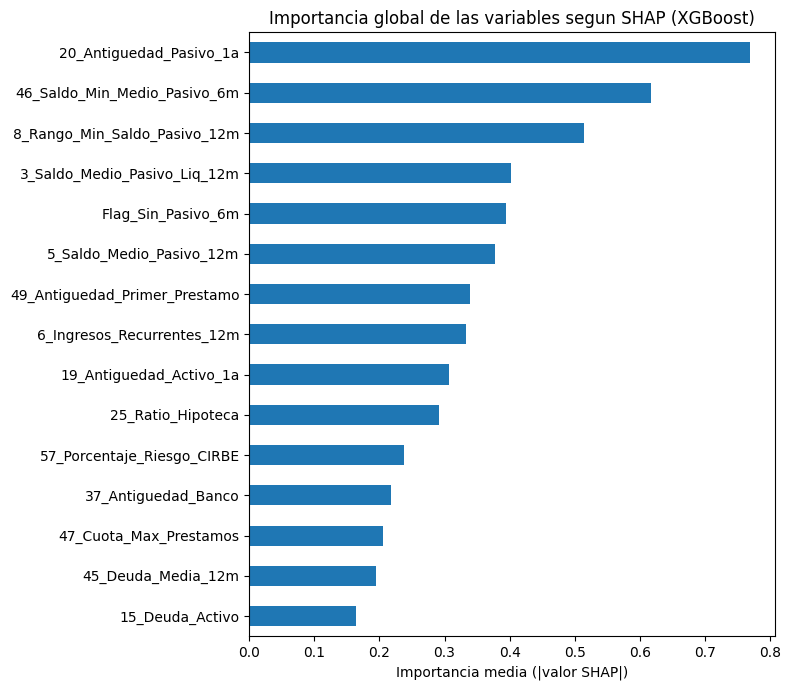

Valor base del modelo (log-odds): -2.642

Top 10 variables por importancia SHAP:
20_Antiguedad_Pasivo_1a          0.7691
46_Saldo_Min_Medio_Pasivo_6m     0.6179
8_Rango_Min_Saldo_Pasivo_12m     0.5142
3_Saldo_Medio_Pasivo_Liq_12m     0.4016
Flag_Sin_Pasivo_6m               0.3941
5_Saldo_Medio_Pasivo_12m         0.3776
49_Antiguedad_Primer_Prestamo    0.3396
6_Ingresos_Recurrentes_12m       0.3337
19_Antiguedad_Activo_1a          0.3074
25_Ratio_Hipoteca                0.2919


In [3]:
# Valores SHAP mediante el motor nativo de XGBoost (exacto para árboles).
# La matriz tiene una columna por variable más una final con el valor base.
booster = xgb_model.get_booster()
dtest = xgb.DMatrix(X_test, feature_names=FEATURES)
contribs = booster.predict(dtest, pred_contribs=True)
shap_values = contribs[:, :-1]
valor_base  = float(contribs[0, -1])

# Importancia global: media del valor absoluto de los SHAP por variable
importancia = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
importancia.head(15).iloc[::-1].plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_xlabel("Importancia media (|valor SHAP|)")
ax.set_title("Importancia global de las variables segun SHAP (XGBoost)")
plt.tight_layout()
plt.savefig("../reports/figures/04b_shap_importancia.png", dpi=150, bbox_inches="tight")
plt.show()

print("Valor base del modelo (log-odds):", round(valor_base, 3))
print("\nTop 10 variables por importancia SHAP:")
print(importancia.head(10).round(4).to_string())

El resultado confirma, desde otro ángulo, la decisión tomada en el notebook 03: una vez retiradas X53 y X48, ninguna variable domina el modelo. La más importante, **20_Antiguedad_Pasivo_1a** (antigüedad de la cuenta más antigua, importancia 0,77), apenas duplica a la última del top 5, **Flag_Sin_Pasivo_6m** (0,39), y a partir de ahí la importancia decae de forma gradual. Esta es justamente la firma que cabe esperar de un riesgo multifactorial, en contraste con la concentración extrema que mostraban X53 y X48.

El top 10 lo completan variables de saldo (X46, X8, X3, X5), antigüedad (X49, X19) e ingresos (X6, X25). En la mayoría, la dirección del efecto es la esperable: a menor saldo o rango de saldo, mayor riesgo, coherente con la lectura del EDA. Pero dos variables muestran un comportamiento que conviene señalar, no ocultar, porque no encaja con la intuición de negocio:

- **20_Antiguedad_Pasivo_1a**: una antigüedad de cuenta mayor empuja el riesgo **hacia arriba**, no hacia abajo, en el modelo. Es el mismo patrón, contraintuitivo, que documenta Mallo para X19 (Antigüedad_Activo) en su propio modelo, lo que sugiere que no es un artefacto de este trabajo, sino una regularidad real de los datos que ninguna de las dos metodologías explica del todo.
- **Flag_Sin_Pasivo_6m**: no tener saldo en cuenta corriente en los últimos 6 meses se asocia a **menor** riesgo, no a mayor. Es lo contrario de lo que cabría esperar de un indicador de ausencia de vínculo con el banco, y lo contrario también de lo que mostraba Flag_Sin_Pasivo_NoVista en el EDA del notebook 01. Ambos Flags señalan ausencia de pasivo, pero en periodos y conceptos distintos, y aquí apuntan en direcciones opuestas: una asimetría que queda señalada como observación para trabajo futuro, sin una explicación causal verificada en este estudio.

En el extremo opuesto, tres de los cinco *Flags* de ausencia (Flag_Sin_Primer_Prestamo, Flag_Sin_Ratio_Pagos y Flag_Sin_Prestamo) conservan una importancia marginal, en los últimos puestos del ranking de 28 variables. Solo Flag_Sin_Pasivo_6m resulta relevante, y solo una vez que X53 y X48 dejan de monopolizar la señal: con ellas presentes (notebook 03), este Flag pasaba inadvertido; sin ellas, emerge como una de las variables más informativas del conjunto.

El gráfico siguiente, llamado ***beeswarm*** (enjambre de abejas, por su aspecto), muestra la misma información con mucho más detalle. Conviene entender cómo se lee:

- Cada **fila** es una variable, ordenadas de arriba (más importante) a abajo (menos importante).
- Cada **punto** es un cliente. Como hay miles, se amontonan formando el "enjambre".
- La **posición horizontal** del punto es su valor SHAP: a la derecha, esa variable empuja a ese cliente hacia el impago; a la izquierda, lo aleja.
- El **color** indica el valor que tiene la variable para ese cliente: rojo si es alto, azul si es bajo.

La clave está en **combinar posición y color**, porque así se ve en qué sentido actúa cada variable. Por ejemplo, para X46 (saldo mínimo medio del pasivo): si los puntos azules (clientes con saldo alto) se agrupan a la izquierda y los rojos (saldo bajo) a la derecha, la lectura es directa: *cuanto menor es el saldo, mayor es el riesgo de impago*. Un patrón de colores invertido indicaría lo contrario.

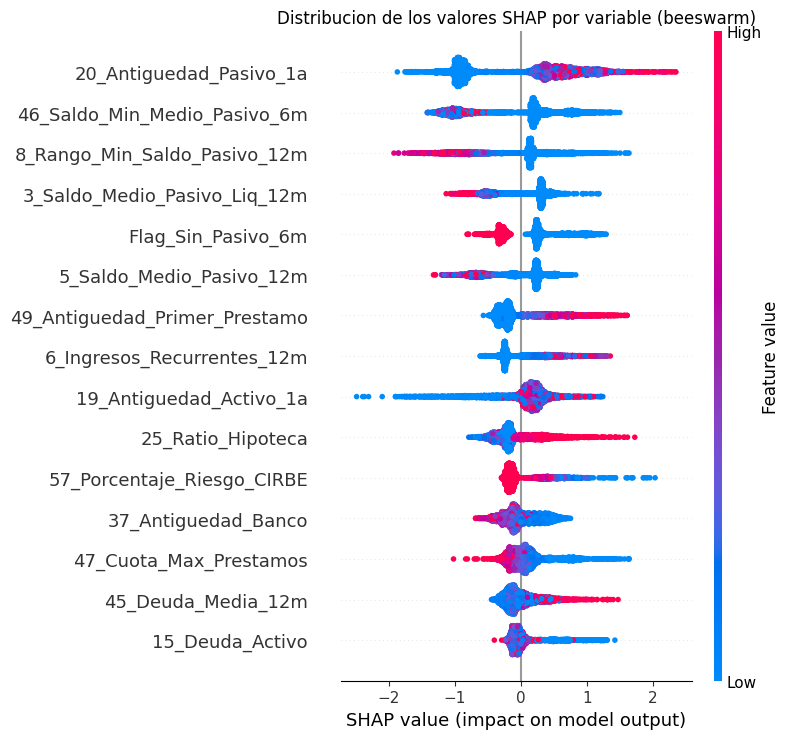

In [4]:
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("Distribucion de los valores SHAP por variable (beeswarm)")
plt.tight_layout()
plt.savefig("../reports/figures/04b_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

El *beeswarm* confirma, en primer lugar, que la importancia está ahora repartida: no hay una sola fila con una nube de puntos mucho más extendida que las demás, como ocurría con X53 y X48. La mayoría de las variables de saldo (X46, X8, X3, X5) muestran el patrón esperable, con los puntos azules (valores altos de saldo) a la izquierda y los rojos (valores bajos) a la derecha: a menos liquidez, más riesgo.

X20 (antigüedad del pasivo) rompe ese patrón: los puntos rojos (mayor antigüedad) se sitúan a la derecha, empujando hacia el impago, justo lo contrario de lo que cabría esperar de una variable que en el EDA se interpretó como señal de fidelidad. El mismo gráfico permite ver que Flag_Sin_Pasivo_6m actúa también en sentido inverso al esperado: los clientes marcados con el Flag (sin saldo en cuenta corriente en 6 meses) se concentran en valores SHAP negativos, es decir, de menor riesgo. Ambas anomalías quedan documentadas aquí como observaciones del modelo sobre los datos, no como errores de cálculo, y se señalan como líneas de revisión futura en las conclusiones del trabajo.

Las variables de la mitad inferior del gráfico muestran nubes de puntos mucho más estrechas y centradas en el cero: su contribución a cada predicción individual es pequeña, aunque conjuntamente sigan aportando algo de señal.

## 4b.4 Curva de parsimonia: ¿cuántas variables son necesarias?

La importancia SHAP ordena las variables de la más a la menos relevante. La **curva de parsimonia** aprovecha ese orden para responder a una pregunta práctica: ¿cuántas variables hacen falta realmente?

El procedimiento consiste en entrenar el modelo primero con la variable más importante, luego con las dos más importantes, después con las tres, y así sucesivamente, midiendo en cada paso el AUC y el KS sobre test. Si la curva se estabiliza a partir de un número reducido de variables, significa que las restantes no aportan capacidad discriminante y pueden descartarse, obteniendo un modelo más simple e interpretable sin sacrificar rendimiento.

El **orden** de entrada de las variables se calcula con los valores SHAP sobre **train**, no sobre test: decidir qué variables entran primero es una decisión de selección, y usar el test para tomarla contaminaría la evaluación final que se hace con ese mismo conjunto. El test se reserva exclusivamente para medir el AUC y el KS de cada subconjunto ya elegido.

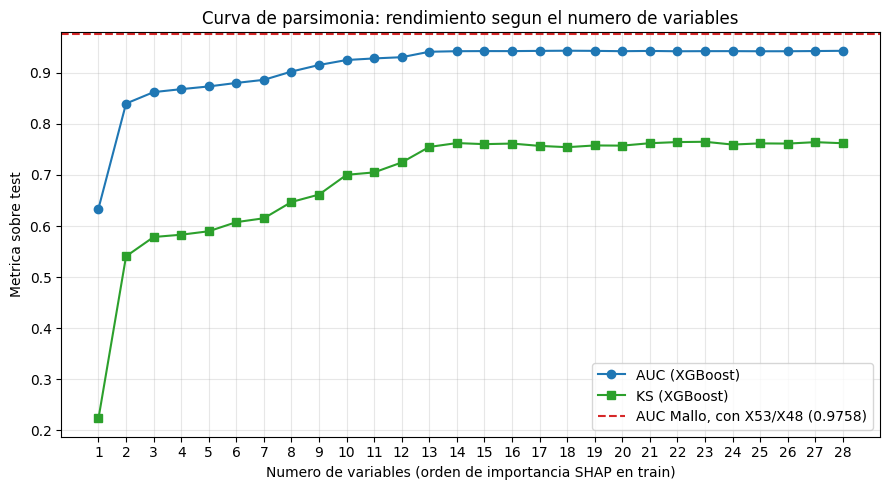

 Nº variables    AUC     KS
            1 0.6344 0.2235
            2 0.8399 0.5408
            3 0.8623 0.5786
            4 0.8681 0.5831
            5 0.8734 0.5898
            6 0.8803 0.6077
            8 0.9025 0.6471
           10 0.9252 0.7004
           12 0.9307 0.7246
           15 0.9427 0.7604
           20 0.9425 0.7575
           28 0.9432 0.7622

Orden de entrada (primeras 12 variables, importancia SHAP en train):
['20_Antiguedad_Pasivo_1a', '46_Saldo_Min_Medio_Pasivo_6m', '8_Rango_Min_Saldo_Pasivo_12m', '3_Saldo_Medio_Pasivo_Liq_12m', 'Flag_Sin_Pasivo_6m', '5_Saldo_Medio_Pasivo_12m', '6_Ingresos_Recurrentes_12m', '49_Antiguedad_Primer_Prestamo', '19_Antiguedad_Activo_1a', '25_Ratio_Hipoteca', '57_Porcentaje_Riesgo_CIRBE', '37_Antiguedad_Banco']


In [5]:
# Importancia SHAP sobre TRAIN, usada únicamente para fijar el orden de entrada de las variables
dtrain = xgb.DMatrix(X_train, feature_names=FEATURES)
contribs_train = xgb_model.get_booster().predict(dtrain, pred_contribs=True)
shap_values_train = contribs_train[:, :-1]
importancia_train = pd.Series(np.abs(shap_values_train).mean(axis=0), index=FEATURES).sort_values(ascending=False)

orden = importancia_train.index.tolist()  # variables ordenadas por importancia SHAP en train
ks_de = lambda y, p: (lambda f: (f[1] - f[0]).max())(roc_curve(y, p)[:2])

ks_list, auc_list, ks_vals, ns = [], [], [], list(range(1, len(orden) + 1))
for k in ns:
    cols = orden[:k]
    m_k = entrenar_xgb(cols)
    p_k = m_k.predict_proba(X_test[cols])[:, 1]
    auc_list.append(roc_auc_score(y_test, p_k))
    fpr, tpr, _ = roc_curve(y_test, p_k)
    ks_vals.append((tpr - fpr).max())

AUC_MALLO = 0.9758
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ns, auc_list, "o-", color="#1f77b4", label="AUC (XGBoost)")
ax.plot(ns, ks_vals, "s-", color="#2ca02c", label="KS (XGBoost)")
ax.axhline(AUC_MALLO, ls="--", color="#d62728", label=f"AUC Mallo, con X53/X48 ({AUC_MALLO})")
ax.set_xlabel("Numero de variables (orden de importancia SHAP en train)")
ax.set_ylabel("Metrica sobre test")
ax.set_title("Curva de parsimonia: rendimiento segun el numero de variables")
ax.set_xticks(ns); ax.grid(alpha=0.3); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/figures/04b_parsimonia.png", dpi=150, bbox_inches="tight")
plt.show()

tabla = pd.DataFrame({"Nº variables": ns, "AUC": np.round(auc_list, 4), "KS": np.round(ks_vals, 4)})
print(tabla[tabla["Nº variables"].isin([1,2,3,4,5,6,8,10,12,15,20,28])].to_string(index=False))
print("\nOrden de entrada (primeras 12 variables, importancia SHAP en train):")
print(orden[:12])

La curva, sin X53 ni X48, cuenta una historia distinta a la que mostraba el conjunto completo:

- Con **una sola variable** (20_Antiguedad_Pasivo_1a) el AUC se queda en 0,634: un poder discriminante modesto, lejos todavía de un buen modelo, señal de que ninguna variable aislada concentra ya la capacidad predictiva.

- Con **dos** variables sube de golpe a 0,840, y con **cuatro** a 0,868. El salto más fuerte ocurre al incorporar la segunda variable; a partir de ahí la mejora es mucho más gradual.

- La curva entra en una meseta a partir de las **15 variables** (AUC 0,943), y apenas gana una milésima hasta las 28 (0,943). A diferencia del conjunto completo, **ninguna combinación de variables alcanza aquí el benchmark de Mallo (0,9758)**: la distancia que separa a este modelo de esa referencia no se cierra añadiendo más variables, porque la propia referencia depende de las dos que se han excluido.

La conclusión práctica cambia respecto a la versión con X53 y X48. El modelo sigue sin necesitar las 28 variables: con 12, las del tamaño del modelo de Mallo, se recupera ya el 98,7% del AUC que se obtiene con el conjunto completo (0,9307 frente a 0,9432), y a partir de 15 el margen de mejora es mínimo. Pero ya no existe un atajo de 4 o 5 variables que sustituya con ventaja al benchmark de referencia: la parsimonia sigue siendo alcanzable, simplemente ya no promete superar a Mallo por el camino corto.

## 4b.5 El conjunto representativo y su comparación con Mallo

La curva de parsimonia anterior mostraba que el número de variables puede ajustarse al objetivo. En esta sección se toman las **doce variables más importantes** según SHAP con un propósito concreto: compararlas con la selección de Mallo **en igualdad de condiciones**. Su modelo final (*mod12AIC*) también se quedó con doce variables, así que se elige el mismo número, no porque doce sea un valor óptimo, sino para poder contrastar variable a variable si el criterio automático de este trabajo (importancia SHAP) coincide con el criterio que Mallo aplicó combinando *stepAIC* y juicio experto.

In [6]:
vars_mallo = [
    "8_Rango_Min_Saldo_Pasivo_12m", "19_Antiguedad_Activo_1a", "25_Ratio_Hipoteca",
    "46_Saldo_Min_Medio_Pasivo_6m", "47_Cuota_Max_Prestamos", "48_Meses_Descubierto_12m",
    "49_Antiguedad_Primer_Prestamo", "53_Porcentaje_Contratos_Incidencia",
    "55_Ratio_Pasivo_NoVista_Total", "57_Porcentaje_Riesgo_CIRBE", "58_Edad",
    "63_Recibos_NoBasicos_3m",
]
top12 = orden[:12]
comunes = sorted(set(top12) & set(vars_mallo))
solo_shap  = sorted(set(top12) - set(vars_mallo))
solo_mallo = sorted(set(vars_mallo) - set(top12))

print(f"Variables comunes a ambas selecciones: {len(comunes)} de 12\n")
print("En ambas (SHAP y Mallo):")
for v in comunes: print("  -", v)
print("\nSolo en el top-12 SHAP de este trabajo:")
for v in solo_shap: print("  -", v)
print("\nSolo en el modelo de Mallo:")
for v in solo_mallo: print("  -", v)

Variables comunes a ambas selecciones: 6 de 12

En ambas (SHAP y Mallo):
  - 19_Antiguedad_Activo_1a
  - 25_Ratio_Hipoteca
  - 46_Saldo_Min_Medio_Pasivo_6m
  - 49_Antiguedad_Primer_Prestamo
  - 57_Porcentaje_Riesgo_CIRBE
  - 8_Rango_Min_Saldo_Pasivo_12m

Solo en el top-12 SHAP de este trabajo:
  - 20_Antiguedad_Pasivo_1a
  - 37_Antiguedad_Banco
  - 3_Saldo_Medio_Pasivo_Liq_12m
  - 5_Saldo_Medio_Pasivo_12m
  - 6_Ingresos_Recurrentes_12m
  - Flag_Sin_Pasivo_6m

Solo en el modelo de Mallo:
  - 47_Cuota_Max_Prestamos
  - 48_Meses_Descubierto_12m
  - 53_Porcentaje_Contratos_Incidencia
  - 55_Ratio_Pasivo_NoVista_Total
  - 58_Edad
  - 63_Recibos_NoBasicos_3m


Coinciden **seis de las doce variables**: X19, X25, X46, X49, X57 y X8. Dos de las seis que faltan para llegar al nivel de coincidencia anterior (ocho de doce, cuando X53 y X48 formaban parte del conjunto) son una consecuencia mecánica de la decisión del notebook 03: ni X53 ni X48 pueden aparecer ya en el top-12 de este trabajo, porque no entran en el modelo. La comparación relevante no es, por tanto, ocho frente a seis sin más, sino qué ocurre con las diez variables que sí podían competir en igualdad de condiciones: de esas diez, **seis siguen coincidiendo**, una proporción similar a la que ya mostraba la versión con el conjunto completo.

Las diferencias restantes son, además, intercambios concretos y no una divergencia generalizada. Mallo retiene **X47 (cuota máxima de préstamos)**, que en este trabajo queda justo fuera del top-12, mientras que aquí entra **X49 (antigüedad del primer préstamo)**, que antes quedaba fuera. A esto se suman variables de saldo y vinculación que el modelo no lineal aprovecha y que no formaban parte de la selección de Mallo: **X3, X5 y X20** (saldos y antigüedad del pasivo), además del **Flag_Sin_Pasivo_6m**, que solo emerge como relevante una vez que X53 y X48 dejan de dominar la señal (sección 4b.3). Mallo, por su parte, retiene también **X55, X58 (edad) y X63**, que aquí no llegan a entrar en el top-12.

La lectura honesta es la siguiente: una vez resuelto el problema de fuga, las dos metodologías siguen señalando un núcleo común de variables de saldo, antigüedad y riesgo en CIRBE, lo que sigue validando de forma cruzada ambos enfoques. Pero la coincidencia ya no alcanza a las dos variables más extremas, que dejaron de estar disponibles para este trabajo precisamente por la razón que motivó excluirlas.

## 4b.6 Explicación individual: los *reason codes*

La importancia global dice qué variables pesan en el modelo en su conjunto, pero la entidad necesita algo más concreto: explicar **cada decisión individual**. Aquí es donde SHAP aporta su mayor valor, ya que descompone la predicción de un cliente concreto en la contribución de cada una de sus variables.

El siguiente gráfico de cascada (*waterfall*) parte del valor base (la predicción media, en *log-odds*) y va sumando la contribución de cada variable hasta llegar a la predicción final del cliente. Las barras rojas empujan hacia el impago y las azules en sentido contrario. Esto constituye un *reason code*: la justificación auditable de por qué el modelo considera a ese cliente de alto o bajo riesgo.

Conviene una precisión previa: el modelo no concede ni deniega por sí mismo, sino que estima una **probabilidad de impago**. Es la entidad quien fija el **umbral** a partir del cual rechaza una solicitud, y esa es una decisión de negocio, no estadística, que depende del coste que el banco asigne a cada tipo de error (cuestión analizada en la sección 4.6 del notebook 04). En los ejemplos que siguen se toma como referencia el umbral por defecto de **0,5**: se consideraría denegable todo cliente cuya probabilidad estimada de impago lo supere. Una entidad más conservadora podría rebajar ese umbral (por ejemplo, al punto de Youden, en torno a 0,10) para detectar más impagos, a costa de rechazar también a algunos buenos pagadores.

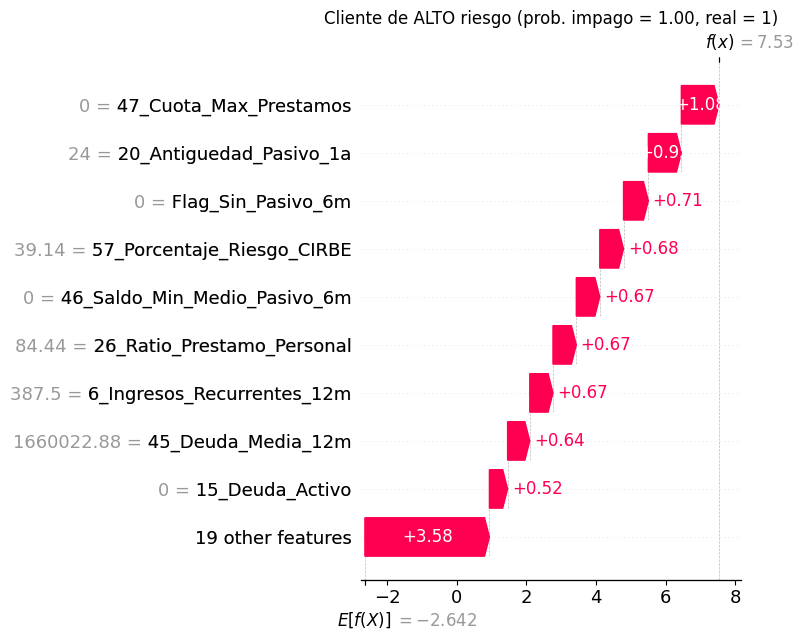

In [7]:
prob_test = xgb_model.predict_proba(X_test)[:, 1]
i_alto = int(np.argmax(prob_test))   # cliente de mayor riesgo estimado
i_bajo = int(np.argmin(prob_test))   # cliente de menor riesgo estimado

expl_alto = shap.Explanation(values=shap_values[i_alto], base_values=valor_base,
                             data=X_test.iloc[i_alto].values, feature_names=FEATURES)
shap.plots.waterfall(expl_alto, max_display=10, show=False)
plt.title(f"Cliente de ALTO riesgo (prob. impago = {prob_test[i_alto]:.2f}, real = {int(y_test.iloc[i_alto])})")
plt.tight_layout()
plt.savefig("../reports/figures/04b_reason_alto_riesgo.png", dpi=150, bbox_inches="tight")
plt.show()

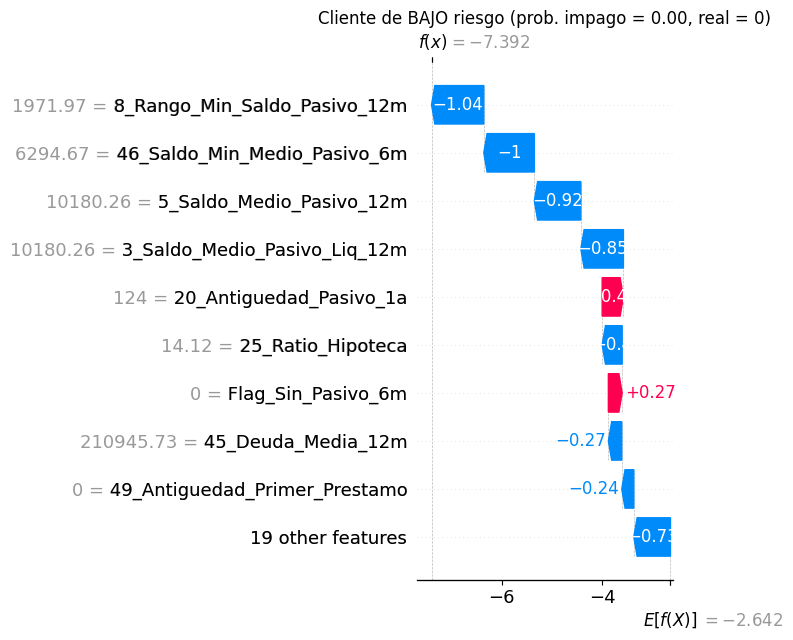

In [8]:
expl_bajo = shap.Explanation(values=shap_values[i_bajo], base_values=valor_base,
                             data=X_test.iloc[i_bajo].values, feature_names=FEATURES)
shap.plots.waterfall(expl_bajo, max_display=10, show=False)
plt.title(f"Cliente de BAJO riesgo (prob. impago = {prob_test[i_bajo]:.2f}, real = {int(y_test.iloc[i_bajo])})")
plt.tight_layout()
plt.savefig("../reports/figures/04b_reason_bajo_riesgo.png", dpi=150, bbox_inches="tight")
plt.show()

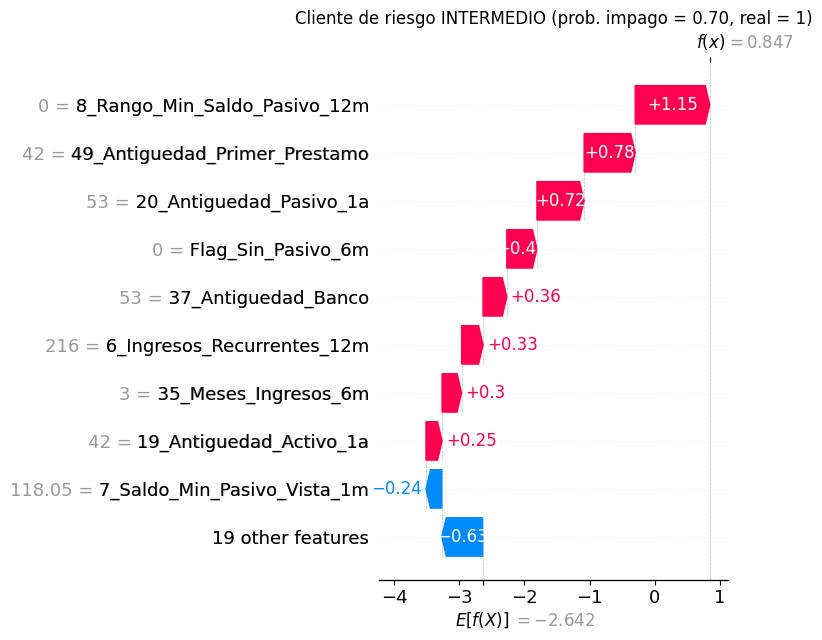

In [9]:
# Tercer caso: cliente de riesgo intermedio (probabilidad cercana a 0,70),
# mucho mas representativo de las decisiones reales que los dos extremos.
i_medio = int(np.argmin(np.abs(prob_test - 0.70)))

expl_medio = shap.Explanation(values=shap_values[i_medio], base_values=valor_base,
                              data=X_test.iloc[i_medio].values, feature_names=FEATURES)
shap.plots.waterfall(expl_medio, max_display=10, show=False)
plt.title(f"Cliente de riesgo INTERMEDIO (prob. impago = {prob_test[i_medio]:.2f}, real = {int(y_test.iloc[i_medio])})")
plt.tight_layout()
plt.savefig("../reports/figures/04b_reason_intermedio.png", dpi=150, bbox_inches="tight")
plt.show()

Los tres ejemplos, ya sobre el modelo sin X53 ni X48, ilustran el mecanismo con un perfil de variables mucho más variado que antes, sin dos factores que concentren la explicación:

- El **cliente de alto riesgo** (probabilidad de impago estimada del 99,9%, e impagador real) acumula varios factores en la misma dirección: no tiene ninguna cuota de préstamo vigente (X47 = 0), tiene una cuenta antigua (X20 = 24, el signo contraintuitivo descrito en 4b.3), sí ha mantenido saldo en cuenta corriente en los últimos seis meses (Flag_Sin_Pasivo_6m = 0, lo que aquí empuja el riesgo hacia arriba, también en sentido inverso al esperado) y concentra un porcentaje bajo de su deuda total en esta entidad frente al resto del sistema (X57 = 39%), junto con un préstamo personal todavía pendiente en un 84% (X26). Ninguna de estas variables por sí sola sería decisiva; combinadas, sí.

- El **cliente de bajo riesgo** (probabilidad prácticamente nula, y pagador real) presenta el perfil contrario en las variables de saldo: un rango de saldo amplio (X8 ≈ 1.972€), un saldo mínimo medio elevado en los últimos seis meses (X46 ≈ 6.295€) y saldos medios altos en pasivo (X3 y X5 ≈ 10.180€), todos con contribuciones negativas que alejan del impago. Es interesante que, aun así, su antigüedad de cuenta (X20 = 124) empuja ligeramente en sentido contrario (shap +0,42): el patrón contraintuitivo de esa variable aparece también en un cliente que, en conjunto, es de bajo riesgo, y queda simplemente compensado por el peso mayor de los saldos.

- El **cliente de riesgo intermedio** (probabilidad del 70%, que con el umbral de 0,5 motivaría la denegación) combina un rango de saldo nulo (X8 = 0, el mayor empuje hacia el impago), una antigüedad relativamente alta tanto en el primer préstamo (X49 = 42 meses) como en la cuenta (X20 = 53) y, de nuevo, el haber mantenido saldo en cuenta corriente en los últimos seis meses (Flag_Sin_Pasivo_6m = 0). Es un perfil donde varias señales moderadas se suman, en lugar de uno o dos factores extremos que decidan por sí solos.

El contraste con los ejemplos del modelo que sí incluía X53 y X48 es instructivo: aquellos *reason codes* se resumían casi siempre en una o dos variables dominantes; estos combinan entre cuatro y seis factores de magnitud similar. Para la entidad, el *reason code* sigue siendo trazable variable por variable, pero ya no se reduce a una frase única ("se le deniega por su historial de incidencias"): la justificación es ahora, con más fidelidad, la de un riesgo multifactorial.

## 4b.7 Conclusión

El análisis de interpretabilidad, ya sobre el modelo sin X53 ni X48, resuelve la principal objeción que suele plantearse a los modelos de *machine learning* en banca, su carácter de caja negra, y añade un hallazgo que solo emerge al retirar las variables sospechosas de fuga:

1. **Importancia global.** Los valores SHAP confirman que, sin X53 y X48, el riesgo de impago se reparte entre un grupo amplio de variables de saldo, antigüedad e ingresos, sin que ninguna concentre más de una fracción modesta de la importancia total. Cuatro de los cinco *Flags* de ausencia siguen con importancia marginal, validando la decisión de imputación del notebook 01. La excepción es Flag_Sin_Pasivo_6m, que emerge entre las cinco variables más importantes solo una vez que X53 y X48 dejan de monopolizar la señal, y que junto con la antigüedad del pasivo (X20) muestra una dirección contraria a la intuición de negocio, una observación que queda documentada para trabajo futuro en lugar de forzada a una explicación no verificada.

2. **Parsimonia, sin el atajo anterior.** La curva de parsimonia, ordenada ahora por importancia en train y no en test, muestra que el modelo sigue sin necesitar las 28 variables: con doce, el tamaño del modelo de Mallo, se recupera ya el 98,7% del AUC del conjunto completo. Pero ya no hay un grupo reducido de variables que supere el benchmark de 0,9758 de Mallo, porque esa cifra depende de las dos variables excluidas. La parsimonia sigue siendo una propiedad válida del modelo; superar a Mallo por el camino corto ya no lo es.

3. **Validación cruzada de la selección, con matices.** El conjunto de doce variables seleccionado por importancia SHAP en train coincide en seis con las doce de Mallo, frente a las ocho que coincidían cuando X53 y X48 estaban disponibles para ambas selecciones. De las diez variables de Mallo que sí podían competir en igualdad de condiciones, sin embargo, la coincidencia se mantiene en seis, una proporción similar a la anterior: el núcleo de variables de saldo, antigüedad y riesgo en CIRBE sigue validándose de forma cruzada entre las dos metodologías.

4. **Explicabilidad individual, más repartida.** Los gráficos de cascada generan *reason codes* por cliente que ya no se resumen en una o dos variables dominantes, sino que combinan entre cuatro y seis factores de magnitud comparable. XGBoost conserva la trazabilidad que exige el marco de Basilea II, con una explicación que ahora describe con más fidelidad un riesgo multifactorial.

En conjunto, retirar X53 y X48 no solo corrige una sospecha de fuga de información: cambia la propia naturaleza de la explicación que el modelo ofrece, de una dominada por dos señales casi equivalentes al impago a otra construida sobre un conjunto más amplio y plausible de indicadores de comportamiento financiero. Esa explicación es menos espectacular en sus cifras, pero es la que se puede defender ante un cliente, ante un tribunal y ante el regulador.